# Datasets, DataLoaders y Transforms

Antes de armar el modelo hay que decidir *cómo* llegan las imágenes y anotaciones al entrenamiento, y también *qué transformaciones* queremos aplicarles. En PyTorch esto se reparte generalmente en tres piezas:

- un `Dataset`, que sabe leer *una* muestra `(imagen, objetivo)`
- un `DataLoader`, que agrupa varias muestras en un lote y las entrega en cada paso del optimizador
- y las **transformaciones**, que permiten modificar, normalizar o aumentar los datos tanto para las imágenes como para las anotaciones, usando las herramientas de `torchvision.transforms.v2`

La detección de carros es un buen ejemplo para ver esto: el número de cajas cambia de imagen a imagen, así que el collate por defecto no alcanza y hay que envolver las cajas en `tv_tensors.BoundingBoxes` para que las transformaciones `v2` muevan imagen y objetivo juntos.


In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torchvision.transforms.v2 as transforms
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import tv_tensors

torch.manual_seed(42)


## 1. Un `Dataset` propio

Una subclase de `Dataset` solo necesita tres cosas:

1. `__init__`: leer el archivo de anotaciones y guardar lo necesario para indexar
2. `__len__`: cuántas muestras hay
3. `__getitem__`: construir la pareja `(imagen, objetivo)` del índice pedido

Aquí el CSV tiene *una fila por carro*, así que agrupamos por nombre de imagen
para devolver todas las cajas de ese fotograma. `tv_tensors.BoundingBoxes`
guarda el formato (`XYXY`) y el tamaño del lienzo; sin eso, una rotación o un
volteo movería la imagen y dejaría las cajas en el sitio equivocado.


In [2]:
class Car_Dataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        img_labels = pd.read_csv(annotations_file)
        # Una imagen puede contener varios carros, así que guardamos una entrada por
        # imagen con todas sus cajas apiladas en un arreglo (N, 4)
        self.samples = [
            (name, boxes[["xmin", "ymin", "xmax", "ymax"]].to_numpy(dtype=np.float32))
            for name, boxes in img_labels.groupby("image", sort=True)
        ]
        self.img_dir = img_dir
        # Sin transformación, igual devolvemos un tensor float en [0, 1]
        self.transform = transform or transforms.Compose([
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True)
        ])
        self.target_transform = target_transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_name, boxes = self.samples[idx]
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        # Forma (N, 4), donde N es el número de carros anotados en esta imagen
        bounding_boxes = tv_tensors.BoundingBoxes(
            torch.tensor(boxes, dtype=torch.float32),
            format="XYXY",
            canvas_size=(image.height, image.width)
        )

        # Imagen y cajas viajan juntas por el pipeline
        image, bounding_boxes = self.transform(image, bounding_boxes)

        if self.target_transform:
            bounding_boxes = self.target_transform(bounding_boxes)
        return image, bounding_boxes


car_dataset = Car_Dataset(
    annotations_file='./data/car_detection/bounding_boxes.csv',
    img_dir='./data/car_detection/images'
)
print(f"{len(car_dataset)} fotogramas anotados")
image, boxes = car_dataset[0]
print("Imagen:", image.shape, image.dtype)
print("Cajas:", boxes.shape, boxes.format, boxes.canvas_size)


355 fotogramas anotados
Imagen: torch.Size([3, 380, 676]) torch.float32
Cajas: torch.Size([1, 4]) BoundingBoxFormat.XYXY (380, 676)


## 2. Partición train / val / test

`random_split` no copia los datos: solo reparte índices sobre el mismo
`Dataset`. Fijar la semilla hace que la partición sea reproducible entre
ejecuciones. En la práctica la aumentación suele aplicarse *solo* al conjunto
de entrenamiento; val y test se dejan sin aleatoriedad para medir bien.


In [3]:
total_size = len(car_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

car_train_dataset, car_val_dataset, car_test_dataset = random_split(
    car_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {len(car_train_dataset)}, Val: {len(car_val_dataset)}, Test: {len(car_test_dataset)}")


Train: 248, Val: 53, Test: 54


## 3. `DataLoader` y `collate_fn`

El `DataLoader` pide varias muestras y las convierte en un lote. El collate por
defecto apila tensores con la misma forma; aquí cada imagen puede tener un
número distinto de cajas, así que necesitamos un `collate_fn` propio: las
imágenes sí se apilan en `(B, C, H, W)` y los objetivos quedan como una *lista*
de `B` tensores `(N_i, 4)`.


In [4]:
def collate_detection(batch):
    # Las anotaciones tienen un número variable de cajas, así que no se pueden apilar
    # en un solo tensor: los dejamos como una lista de B tensores de tamaño (N_i, 4)
    images = torch.stack([item[0] for item in batch])  # (B, C, H, W)
    targets = [item[1] for item in batch]              # lista de B tensores (N_i, 4)
    return images, targets


car_train_dataloader = DataLoader(
    car_train_dataset, batch_size=16, shuffle=True, collate_fn=collate_detection
)

samples, bounding_boxes = next(iter(car_train_dataloader))
print("Tamaño de las muestras:", samples.shape)
print("Cajas por imagen en el lote:", [b.shape[0] for b in bounding_boxes])


Tamaño de las muestras: torch.Size([16, 3, 380, 676])
Cajas por imagen en el lote: [1, 1, 5, 1, 1, 2, 3, 2, 2, 2, 2, 1, 2, 1, 1, 1]


Dos funciones auxiliares para las visualizaciones: las imágenes llegan como
tensores `CHW` float en `[0, 1]`, y las cajas se dibujan desde sus esquinas en
formato `XYXY`.


In [5]:
def to_numpy_image(image):
    """Tensor CHW float en [0, 1] -> arreglo HWC que imshow entiende."""
    if isinstance(image, torch.Tensor):
        return image.detach().cpu().permute(1, 2, 0).numpy().clip(0, 1)
    return np.asarray(image)


def draw_boxes(ax, boxes, labels=None, color='red'):
    """Dibuja cajas XYXY sobre un eje existente, con una etiqueta opcional."""
    for i, (xmin, ymin, xmax, ymax) in enumerate(torch.as_tensor(boxes).tolist()):
        ax.add_patch(patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor=color, facecolor='none'
        ))
        if labels is not None:
            ax.text(xmin, ymin - 4, labels[i], color='white', fontsize=8,
                    bbox=dict(facecolor=color, edgecolor='none', pad=1))


## 4. Inspeccionar un lote

Conviene mirar el lote *antes* de entrenar: formas, número de cajas y que las
anotaciones caigan sobre el objeto correcto.


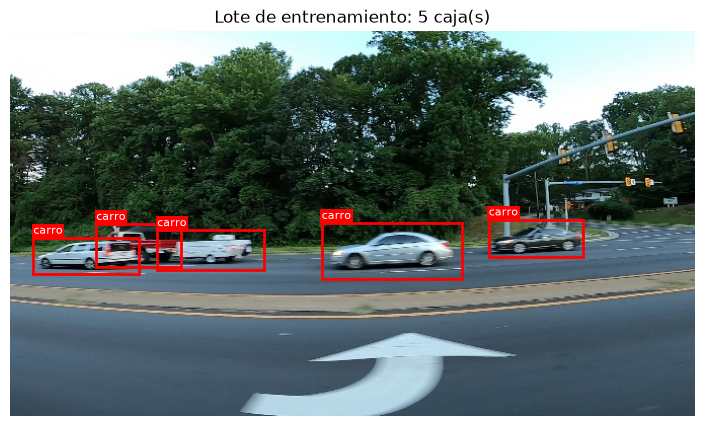

In [6]:
# Mostramos la imagen del lote con el mayor número de carros
idx = max(range(len(bounding_boxes)), key=lambda i: len(bounding_boxes[i]))

fig, ax = plt.subplots(figsize=(9, 5))
ax.imshow(to_numpy_image(samples[idx]))
draw_boxes(ax, bounding_boxes[idx], labels=["carro"] * len(bounding_boxes[idx]))
ax.set_title(f"Lote de entrenamiento: {len(bounding_boxes[idx])} caja(s)")
ax.axis('off')
plt.show()


## 5. Aumentaciones con `transforms.v2`

La razón de envolver las cajas en `tv_tensors` se ve aquí: el mismo
`Compose` de `transforms.v2` actualiza imagen y cajas a la vez. Al final,
`SanitizeBoundingBoxes` descarta las cajas que una rotación sacó fuera de la
imagen (o las dejó degeneradas).

Para el entrenamiento típico se crea un `Dataset` *con* aumentación para train
y otro *sin* ella para val/test, reutilizando el mismo CSV.


In [7]:
train_transforms = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.RandomRotation(degrees=30),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(),
    transforms.SanitizeBoundingBoxes(labels_getter=None),
])

eval_transforms = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
])

car_aug_dataset = Car_Dataset(
    annotations_file='./data/car_detection/bounding_boxes.csv',
    img_dir='./data/car_detection/images',
    transform=train_transforms
)

car_eval_dataset = Car_Dataset(
    annotations_file='./data/car_detection/bounding_boxes.csv',
    img_dir='./data/car_detection/images',
    transform=eval_transforms
)

img, boxes = car_aug_dataset[0]
print("Imagen aumentada:", img.shape, img.dtype)
print("Cajas:", boxes.format, boxes.canvas_size)
print(boxes)


Imagen aumentada: torch.Size([3, 380, 676]) torch.float32
Cajas: BoundingBoxFormat.XYXY (380, 676)
BoundingBoxes([[277.8287, 180.5594, 328.1349, 221.8313]], format=BoundingBoxFormat.XYXY, canvas_size=(380, 676), clamping_mode=soft)


## 6. Partición con aumentación solo en train

Misma proporción que antes, pero ahora el conjunto de entrenamiento apunta al
`Dataset` aumentado y val/test al de evaluación. Así la métrica de validación
no depende de la suerte de una rotación aleatoria.


In [8]:
total_size = len(car_eval_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

# Misma semilla => mismos índices en train / val / test
generator = torch.Generator().manual_seed(42)
train_subset, _, _ = random_split(
    car_aug_dataset, [train_size, val_size, test_size], generator=generator
)
generator = torch.Generator().manual_seed(42)
_, val_subset, test_subset = random_split(
    car_eval_dataset, [train_size, val_size, test_size], generator=generator
)

car_train_dataloader = DataLoader(
    train_subset, batch_size=16, shuffle=True, collate_fn=collate_detection
)
car_val_dataloader = DataLoader(
    val_subset, batch_size=16, shuffle=False, collate_fn=collate_detection
)

print(f"Train (con aug): {len(train_subset)}, Val: {len(val_subset)}, Test: {len(test_subset)}")


Train (con aug): 248, Val: 53, Test: 54


## 7. Ver el efecto de la aumentación

Comparamos la misma imagen *sin* y *con* aumentación. Las cajas deben seguir a
los carros después de la rotación o el volteo; si no lo hacen, el problema casi
siempre está en el tipo del objetivo o en el `canvas_size`.


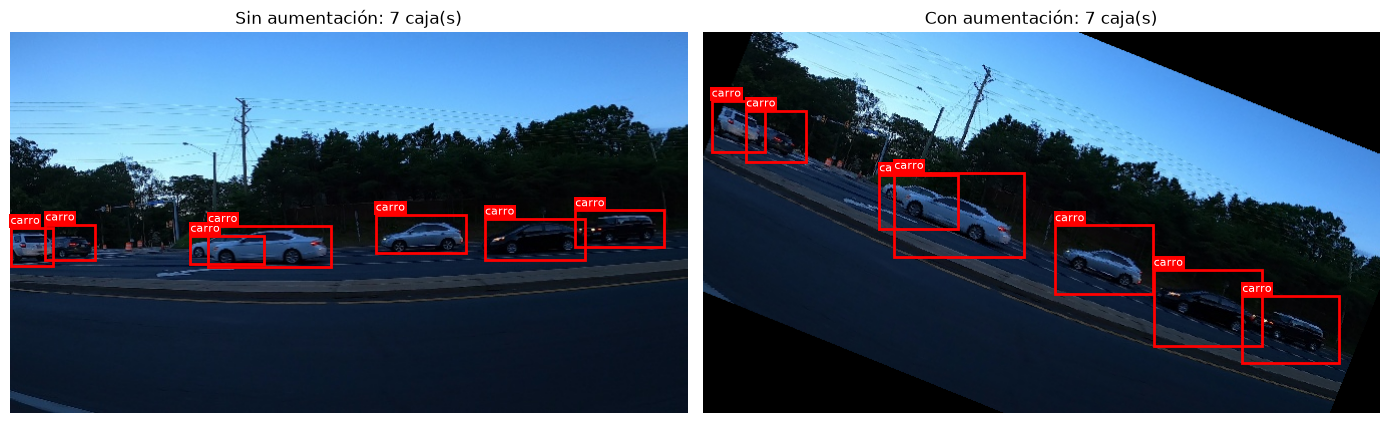

In [9]:
# Elegimos un índice con varias cajas para que el antes/después sea claro
idx = max(range(len(car_eval_dataset)), key=lambda i: len(car_eval_dataset[i][1]))
img_clean, boxes_clean = car_eval_dataset[idx]
img_aug, boxes_aug = car_aug_dataset[idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, image, boxes, title in [
    (axes[0], img_clean, boxes_clean, "Sin aumentación"),
    (axes[1], img_aug, boxes_aug, "Con aumentación"),
]:
    ax.imshow(to_numpy_image(image))
    draw_boxes(ax, boxes, labels=["carro"] * len(boxes))
    ax.set_title(f"{title}: {len(boxes)} caja(s)")
    ax.axis('off')
plt.tight_layout()
plt.show()


## Qué conviene recordar

El patrón de carga casi no cambia entre tareas de visión:

- **`Dataset`**: lee anotaciones en `__init__`, construye `(imagen, objetivo)` en
  `__getitem__` y envuelve el objetivo en el `tv_tensors` adecuado
- **`DataLoader`**: necesita un `collate_fn` propio en cuanto el número de
  objetos anotados varía entre muestras
- **`transforms.v2`**: mueve imagen y anotación juntos; `SanitizeBoundingBoxes`
  limpia lo que la geometría dejó inválido
- **partición**: aumentación en train, transformaciones deterministas en val/test
